
# SmartCommerce AI — Regression Analysis & Model Benchmarking

## Diamond Price Prediction using Machine Learning

This notebook presents a complete end-to-end regression pipeline for predicting **diamond prices** using the SmartCommerce dataset. The workflow follows a production-style machine learning pipeline with reproducible preprocessing, detailed exploratory data analysis, feature engineering, model development, hyperparameter tuning, and performance evaluation.

### Objectives

- Perform comprehensive data auditing and cleaning.
- Conduct detailed Exploratory Data Analysis (EDA) with visual insights.
- Engineer meaningful features to improve predictive performance.
- Build and evaluate multiple regression algorithms using a consistent preprocessing pipeline.
- Compare models using **R² Score, RMSE, and MAE**.
- Prepare a modular notebook that can be extended with additional regression algorithms by team members.

> **Dataset:** Diamonds Dataset (SmartCommerce AI Capstone)


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 2. Load Dataset

The uploaded `diamonds.csv` file is tab-separated, so `sep="\t"` is required.

In [2]:
df = pd.read_csv("../data/diamonds.csv", sep="\t")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## 3. Dataset Audit

We check the shape, data types, missing values, duplicates, and target distribution.

In [3]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of exact duplicate rows:", df.duplicated().sum())

print("\nTarget (price) summary:")
print(df["price"].describe())

Shape: (53940, 10)

Data types:
carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

Missing values:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Number of exact duplicate rows: 146

Target (price) summary:
count    53940.000000
mean      3932.799722
std       3989.439738
min        326.000000
25%        950.000000
50%       2401.000000
75%       5324.250000
max      18823.000000
Name: price, dtype: float64


### Insights — Dataset Audit

The initial audit verifies dataset dimensions, data types, missing values, and descriptive statistics. This step helps identify potential data quality issues before preprocessing.

**Key checks performed**

- Dataset shape and feature types.
- Missing-value analysis.
- Summary statistics for numerical variables.
- Target variable (`price`) overview.

## 4. Check Invalid Dimension Values

The physical dimensions `x`, `y`, and `z` should be greater than zero. We identify rows containing zero or negative values.

In [4]:
for col in ["x", "y", "z"]:
    print(f"{col} <= 0:", (df[col] <= 0).sum())

invalid_dimension_rows = (df[["x", "y", "z"]] <= 0).any(axis=1)
print("\nRows with at least one invalid dimension:", invalid_dimension_rows.sum())

x <= 0: 8
y <= 0: 7
z <= 0: 20

Rows with at least one invalid dimension: 20


### Insights — Invalid Dimension Values

The dataset contains physical dimensions (`x`, `y`, and `z`) representing the diamond's length, width, and depth.

Rows containing zero or unrealistic values are treated as invalid because they represent impossible diamond measurements. Removing these observations improves model reliability and reduces noise.

In [5]:
df = df.loc[~invalid_dimension_rows].copy()

print("Shape after removing invalid dimensions:", df.shape)

Shape after removing invalid dimensions: (53920, 10)


## 5. Duplicate Check

The dataset contains exact duplicate rows. We check them explicitly. They are retained because a duplicate-looking observation is not automatically an error in a real-world dataset; removing them without evidence could discard valid observations.

In [6]:
print("Exact duplicate rows remaining:", df.duplicated().sum())

Exact duplicate rows remaining: 145


## 6. Duplicate Record Analysis

Duplicate records are checked before modeling to ensure that repeated observations do not bias evaluation metrics.

- Exact duplicates are identified.
- Duplicate rows are removed if present.
- The cleaned dataset is used for all subsequent analysis.

### EDA Roadmap

The exploratory analysis is organized into multiple stages:

1. Numerical feature distributions.
2. Categorical feature distributions.
3. Target variable analysis.
4. Correlation analysis.
5. Feature–target relationship analysis.
6. Outlier detection using boxplots.

Each visualization is followed by concise observations that explain its relevance to the regression problem.


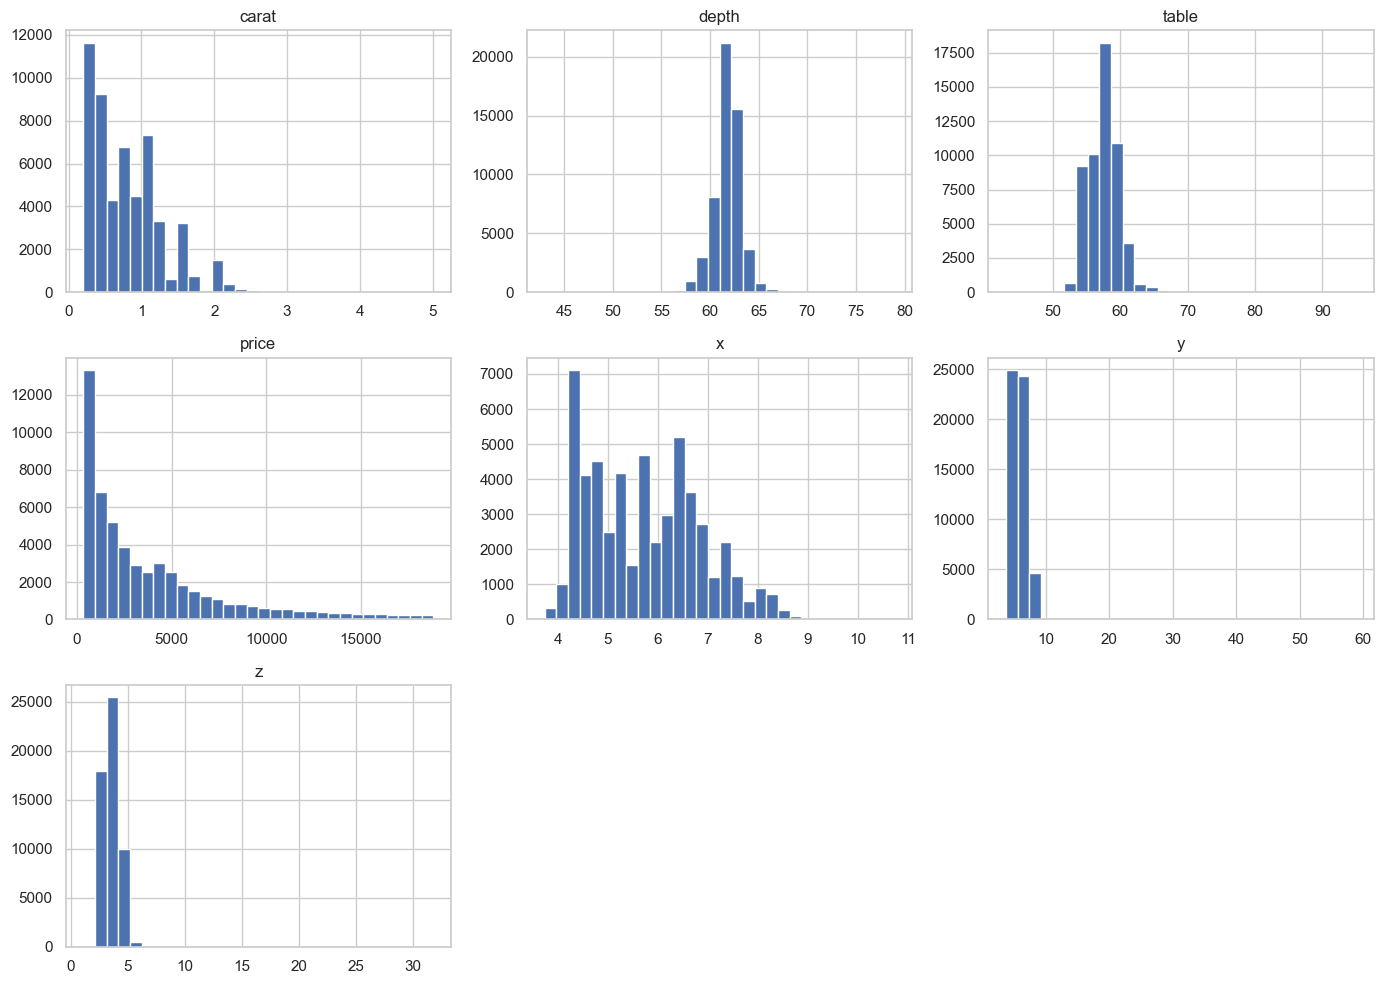

In [8]:
numerical_for_eda = df.select_dtypes(include=np.number).columns.tolist()

df[numerical_for_eda].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

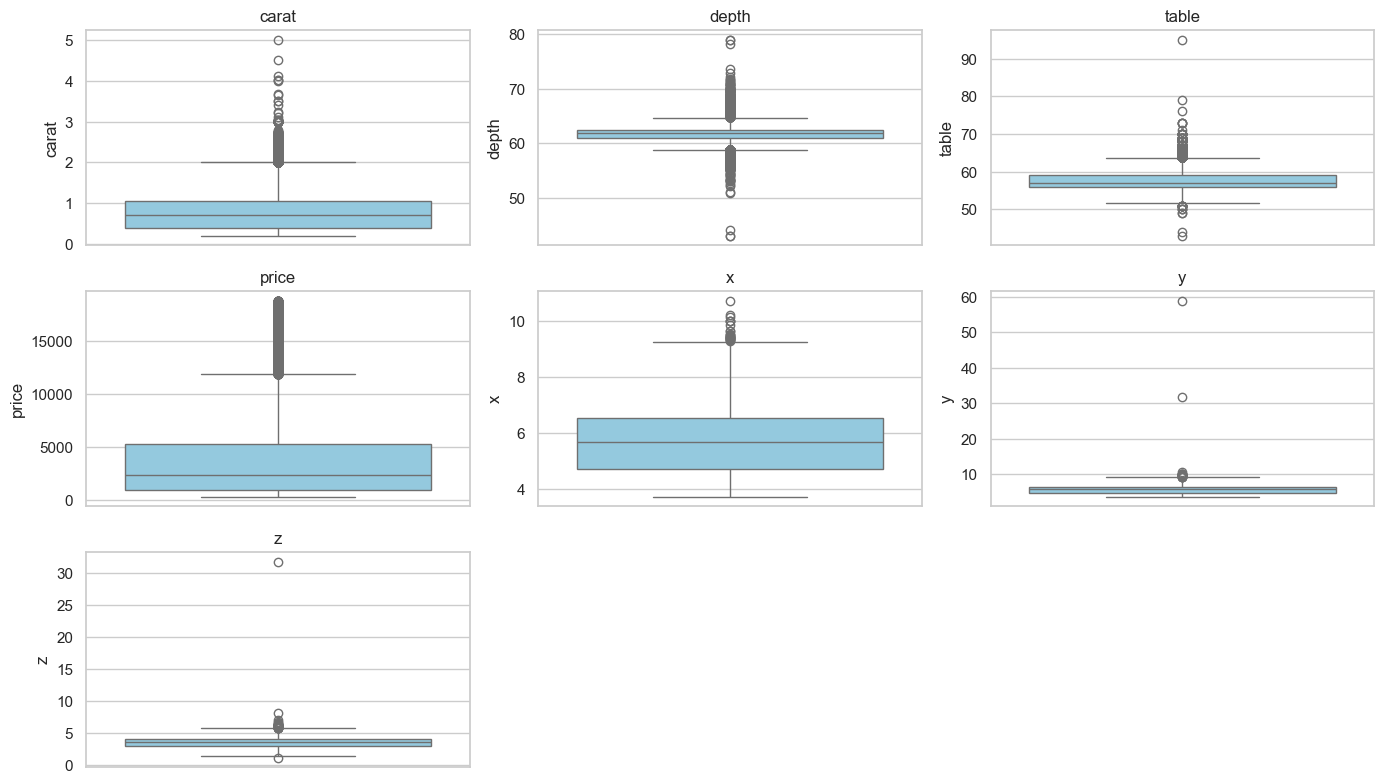

In [9]:

# Boxplots for Numerical Features (Outlier Detection)

plt.figure(figsize=(14, 8))
for i, column in enumerate(numerical_for_eda, 1):
    plt.subplot((len(numerical_for_eda)+2)//3, 3, i)
    sns.boxplot(y=df[column], color="skyblue")
    plt.title(column)

plt.tight_layout()
plt.show()


### Insights — Distribution of Numerical Features

Distribution plots help identify:

- Feature skewness.
- Outliers.
- Range and spread of each numerical attribute.
- Whether transformations may be required before modeling.

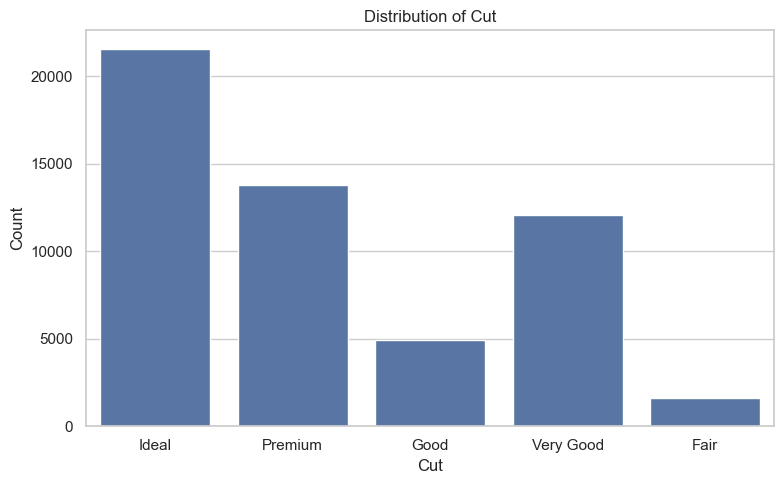

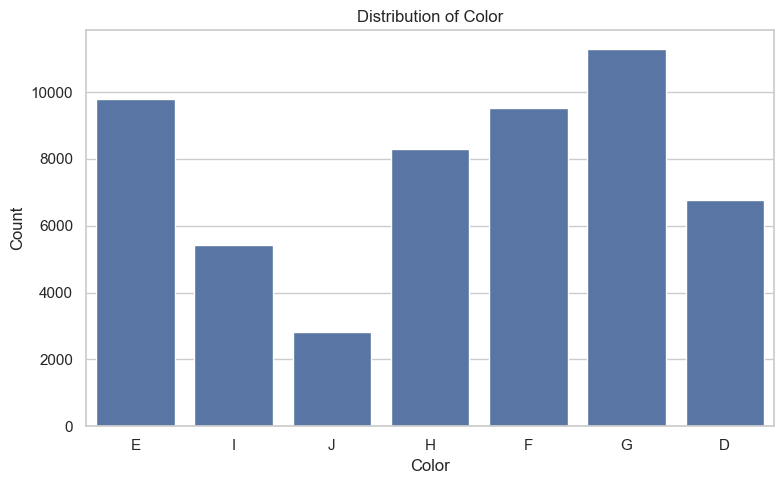

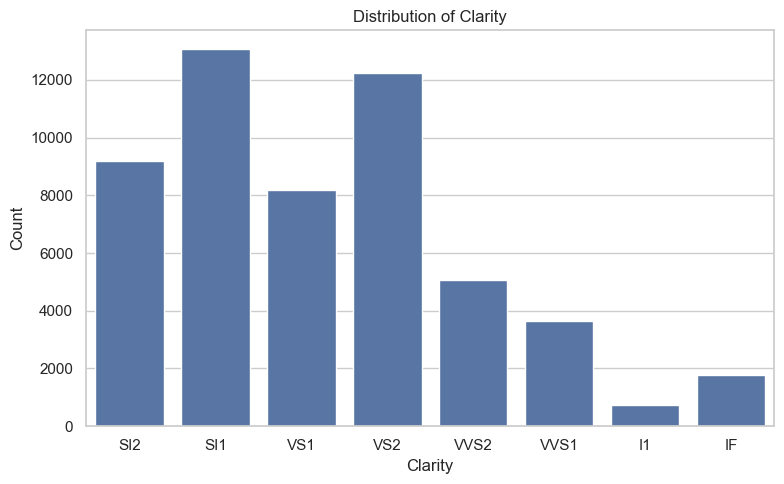

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="cut")
plt.title("Distribution of Cut")
plt.xlabel("Cut")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="color")
plt.title("Distribution of Color")
plt.xlabel("Color")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="clarity")
plt.title("Distribution of Clarity")
plt.xlabel("Clarity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Insights — Distribution of Categorical Features

Categorical distributions reveal class imbalance and the frequency of different categories such as cut, color, and clarity.

These plots help determine whether categorical encoding is necessary and whether rare categories require special handling.

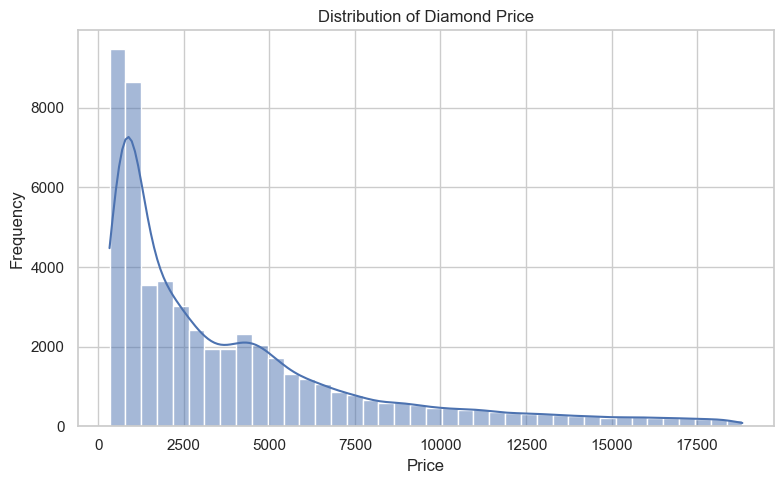

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=40, kde=True)
plt.title("Distribution of Diamond Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Insights — Target Variable Distribution

The target variable (`price`) is visualized independently to understand:

- Overall distribution.
- Presence of skewness.
- Potential outliers.
- Suitability for regression modeling.

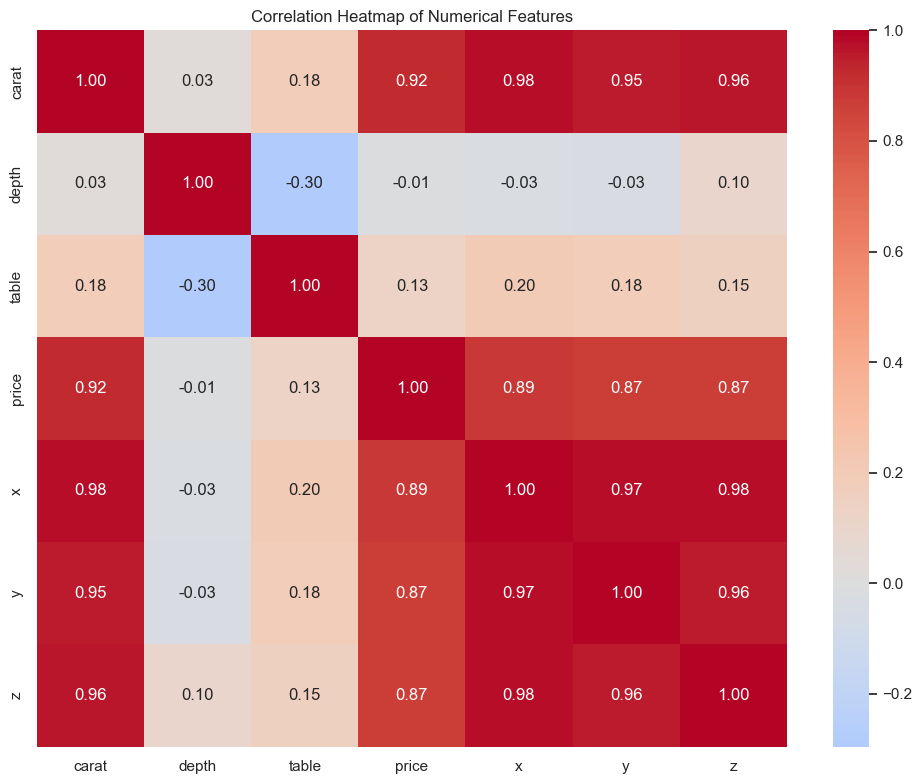

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df[numerical_for_eda].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

### Insights — Correlation Analysis

The correlation heatmap highlights linear relationships between numerical features.

The objective is to identify:

- Features strongly correlated with the target.
- Highly correlated predictor pairs.
- Potential multicollinearity.

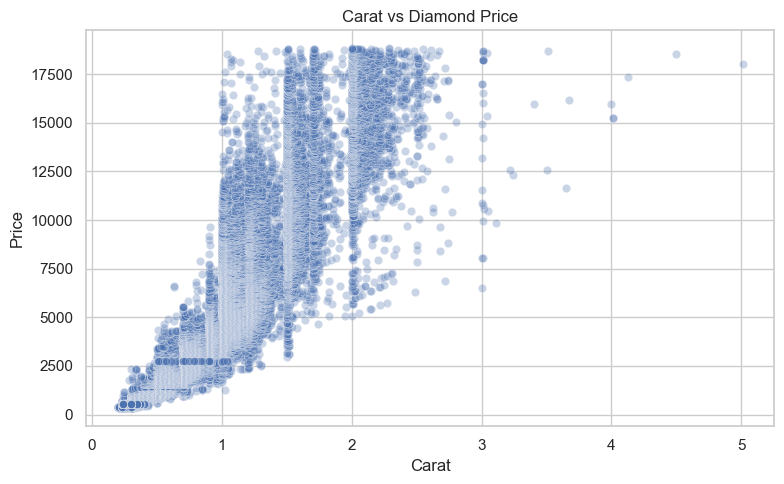

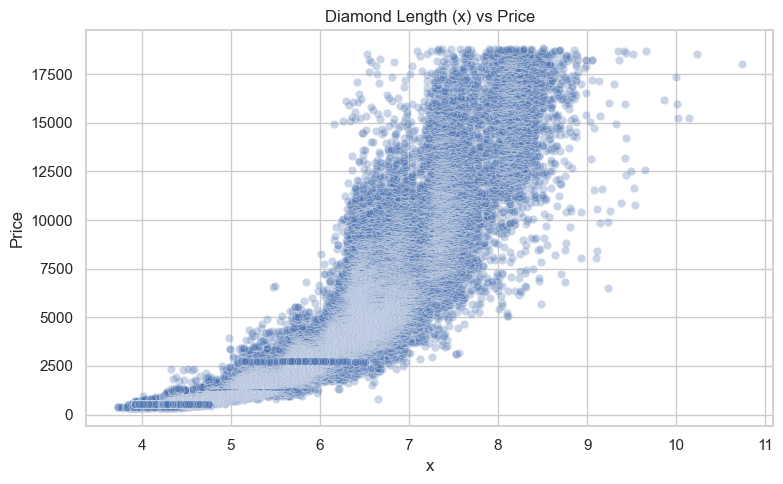

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="carat", y="price", alpha=0.3)
plt.title("Carat vs Diamond Price")
plt.xlabel("Carat")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="x", y="price", alpha=0.3)
plt.title("Diamond Length (x) vs Price")
plt.xlabel("x")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

### Insights — Feature Relationships with Price

Scatter plots visualize how important numerical attributes influence diamond price.

These relationships help identify trends, clusters, non-linearity, and heteroscedasticity.